# 07 · PLE: Reimplement Both Halves, Then Switch It Off

**Hardware**: 🟢 CPU, zero downloads for everything structural. The final section is optional and uses real E2B weights.

## What you will do

1. Reimplement `get_per_layer_inputs` (token identity) and `assert_close` it
2. Reimplement `project_per_layer_inputs` (context aware) including the `1/sqrt(2)` merge
3. See the multimodal branch: soft tokens get only one of the two halves
4. Find where the per-layer input is *actually used* — and confirm it is a **gate**, not an addition
5. Measure how much of the model the PLE table is
6. Zero it out and watch the logits move

In [1]:
%pip install -q "transformers>=5.14" torch matplotlib

In [2]:
import math
import torch
import matplotlib.pyplot as plt
from transformers import Gemma4TextConfig, Gemma4ForCausalLM

torch.manual_seed(0)

config = Gemma4TextConfig(
    vocab_size=512, hidden_size=64, intermediate_size=128,
    num_hidden_layers=12, num_attention_heads=4, num_key_value_heads=1,
    head_dim=16, global_head_dim=32, sliding_window=8,
    hidden_size_per_layer_input=16,        # PLE on
    vocab_size_per_layer_input=512,
    num_kv_shared_layers=0,
)
model = Gemma4ForCausalLM(config).eval()
lm = model.model
input_ids = torch.randint(0, 500, (2, 9))
print("PLE dim:", config.hidden_size_per_layer_input, "| layers:", config.num_hidden_layers)

  from .autonotebook import tqdm as notebook_tqdm


PLE dim: 16 | layers: 12


## 1. The second embedding table

`embed_tokens_per_layer` is a full-vocabulary table whose every row packs that token's contribution to **all** layers end to end.

In [3]:
print("embed_tokens           :", tuple(lm.embed_tokens.weight.shape))
print("embed_tokens_per_layer :", tuple(lm.embed_tokens_per_layer.weight.shape))
print(f"  = vocab_size_per_layer_input x (num_hidden_layers x hidden_size_per_layer_input)")
print(f"  = {config.vocab_size_per_layer_input} x ({config.num_hidden_layers} x {config.hidden_size_per_layer_input})")
print("\nembed_scale (sqrt of the PLE dim):", float(lm.embed_tokens_per_layer.embed_scale),
      "= sqrt(", config.hidden_size_per_layer_input, ") =", math.sqrt(config.hidden_size_per_layer_input))

total = sum(p.numel() for p in model.parameters())
ple = lm.embed_tokens_per_layer.weight.numel()
print(f"\nPLE table is {100 * ple / total:.1f}% of this toy model")

embed_tokens           : (512, 64)
embed_tokens_per_layer : (512, 192)
  = vocab_size_per_layer_input x (num_hidden_layers x hidden_size_per_layer_input)
  = 512 x (12 x 16)

embed_scale (sqrt of the PLE dim): 4.0 = sqrt( 16 ) = 4.0

PLE table is 16.1% of this toy model


The packed layout turns 12 separate embedding lookups into one gather. On E2B the same table is 262144 × (35 × 256) ≈ 2.35B parameters — larger than the rest of the model, but only one row per token is ever read. That is the trade: **memory instead of FLOPs**, which is why PLE is on for E2B/E4B and off (`hidden_size_per_layer_input: 0`) for 31B and 26B-A4B.

## 2. Token identity, by hand

In [4]:
def my_get_per_layer_inputs(lm, input_ids, config):
    packed = lm.embed_tokens_per_layer(input_ids)          # [B, S, layers*ple_dim]
    return packed.reshape(*input_ids.shape,
                          config.num_hidden_layers,
                          config.hidden_size_per_layer_input)


lib_tok = lm.get_per_layer_inputs(input_ids, None)
mine_tok = my_get_per_layer_inputs(lm, input_ids, config)
torch.testing.assert_close(lib_tok, mine_tok)
print("token-identity half matches ✓", tuple(lib_tok.shape), "= [batch, seq, layers, ple_dim]")

token-identity half matches ✓ (2, 9, 12, 16) = [batch, seq, layers, ple_dim]


## 3. Context aware, by hand — and the merge

In [5]:
def my_project_per_layer_inputs(lm, inputs_embeds, per_layer_inputs, config):
    proj = lm.per_layer_model_projection(inputs_embeds) * lm.per_layer_model_projection_scale
    proj = proj.reshape(*inputs_embeds.shape[:-1],
                        config.num_hidden_layers,
                        config.hidden_size_per_layer_input)
    proj = lm.per_layer_projection_norm(proj)
    if per_layer_inputs is None:
        return proj                                        # the multimodal branch
    return (proj + per_layer_inputs) * lm.per_layer_input_scale


inputs_embeds = lm.embed_tokens(input_ids)

lib_full = lm.project_per_layer_inputs(inputs_embeds, lib_tok)
mine_full = my_project_per_layer_inputs(lm, inputs_embeds, lib_tok, config)
torch.testing.assert_close(lib_full, mine_full)
print("full PLE matches ✓")

print("\nper_layer_model_projection_scale =", lm.per_layer_model_projection_scale,
      "= 1/sqrt(hidden_size) =", config.hidden_size ** -0.5)
print("per_layer_input_scale           =", lm.per_layer_input_scale,
      "= 1/sqrt(2) =", 2 ** -0.5)

full PLE matches ✓

per_layer_model_projection_scale = 0.125 = 1/sqrt(hidden_size) = 0.125
per_layer_input_scale           = 0.7071067811865476 = 1/sqrt(2) = 0.7071067811865476


`1/sqrt(2)` is the variance-preserving combination of two roughly unit-variance signals. Nothing exotic — but it tells you the two halves are meant to contribute equally.

## 4. The multimodal branch

A soft token from the vision or audio tower is not in the vocabulary, so there is nothing to look up. Those positions get the context-aware half only.

In [6]:
context_only = lm.project_per_layer_inputs(inputs_embeds, None)
proj_alone = my_project_per_layer_inputs(lm, inputs_embeds, None, config)
torch.testing.assert_close(context_only, proj_alone)
print("context-only branch matches ✓")

print("\nmagnitudes:")
print(f"  token identity : {lib_tok.abs().mean():.4f}")
print(f"  context aware  : {context_only.abs().mean():.4f}")
print(f"  merged         : {lib_full.abs().mean():.4f}")
print("\nA multimodal position therefore gets a per-layer signal that is derived")
print("purely from its image/audio content — which is arguably the point.")

context-only branch matches ✓

magnitudes:
  token identity : 0.0643
  context aware  : 0.7666
  merged         : 0.5420

A multimodal position therefore gets a per-layer signal that is derived
purely from its image/audio content — which is arguably the point.


## 5. Where it is used: a gate, not an addition

The docs call PLE "an auxiliary residual signal". Read the end of `Gemma4TextDecoderLayer.forward` and it is more specific than that.

In [7]:
layer = model.model.layers[0]
print("per_layer_input_gate     :", layer.per_layer_input_gate)
print("per_layer_projection     :", layer.per_layer_projection)
print("post_per_layer_input_norm:", layer.post_per_layer_input_norm)

print(f'''
The layer does:

    residual      = hidden_states
    hidden_states = per_layer_input_gate(hidden_states)   # {config.hidden_size} -> {config.hidden_size_per_layer_input}
    hidden_states = act_fn(hidden_states)
    hidden_states = hidden_states * per_layer_input       # <-- ELEMENTWISE GATE
    hidden_states = per_layer_projection(hidden_states)   # {config.hidden_size_per_layer_input} -> {config.hidden_size}
    hidden_states = post_per_layer_input_norm(hidden_states)
    hidden_states = residual + hidden_states
''')
print("The embedding does not get added to the stream. It MODULATES a low-rank")
print("view of the stream. That is a per-token, per-layer conditioning channel.")

per_layer_input_gate     : Linear(in_features=64, out_features=16, bias=False)
per_layer_projection     : Linear(in_features=16, out_features=64, bias=False)
post_per_layer_input_norm: Gemma4RMSNorm()

The layer does:

    residual      = hidden_states
    hidden_states = per_layer_input_gate(hidden_states)   # 64 -> 16
    hidden_states = act_fn(hidden_states)
    hidden_states = hidden_states * per_layer_input       # <-- ELEMENTWISE GATE
    hidden_states = per_layer_projection(hidden_states)   # 16 -> 64
    hidden_states = post_per_layer_input_norm(hidden_states)
    hidden_states = residual + hidden_states

The embedding does not get added to the stream. It MODULATES a low-rank
view of the stream. That is a per-token, per-layer conditioning channel.


## 6. Ablation

Pass `per_layer_inputs` explicitly to control it. Zero it and the gate closes — every layer's PLE side-branch contributes nothing.

(Weights are random here, so the *magnitude* of the change is not meaningful; what matters is that it is non-zero and grows with depth. Section 7 repeats this with real weights if you have the disk for it.)

PLE zeroed   mean |delta logit| = 0.03522   max = 0.39511
PLE halved   mean |delta logit| = 0.02832   max = 0.36356


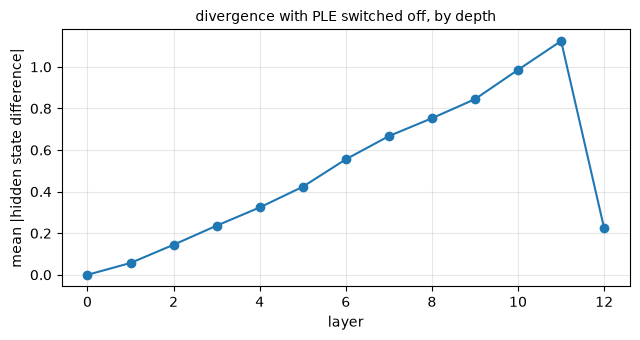

In [8]:
with torch.no_grad():
    base = model(input_ids=input_ids).logits
    zeroed = model(inputs_embeds=inputs_embeds,
                   per_layer_inputs=torch.zeros_like(lib_full)).logits
    halved = model(inputs_embeds=inputs_embeds,
                   per_layer_inputs=lib_full * 0.5).logits

for name, t in [("PLE zeroed", zeroed), ("PLE halved", halved)]:
    print(f"{name:12s} mean |delta logit| = {(base - t).abs().mean():.5f}   "
          f"max = {(base - t).abs().max():.5f}")

# how much does each layer's hidden state drift?
with torch.no_grad():
    h_base = model(input_ids=input_ids, output_hidden_states=True).hidden_states
    h_zero = model(inputs_embeds=inputs_embeds,
                   per_layer_inputs=torch.zeros_like(lib_full),
                   output_hidden_states=True).hidden_states

drift = [ (a - b).abs().mean().item() for a, b in zip(h_base, h_zero) ]
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(drift, marker="o")
ax.set_xlabel("layer"); ax.set_ylabel("mean |hidden state difference|")
ax.set_title("divergence with PLE switched off, by depth", fontsize=10)
ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

The drift compounds: each layer's gate is closed, so the gap widens with depth rather than being corrected downstream.

## 7. Optional: real weights

`google/gemma-4-E2B-it` is ~10GB. If you have the disk and a 24GB GPU, the same ablation on a trained model turns a numerical difference into a visible one — coherent text becomes noise.

In [9]:
RUN_REAL_WEIGHTS = False   # flip to True if you have ~10GB of disk and a 24GB GPU

if RUN_REAL_WEIGHTS:
    from transformers import AutoModelForCausalLM, AutoTokenizer

    mid = "google/gemma-4-E2B-it"
    tok = AutoTokenizer.from_pretrained(mid)
    real = AutoModelForCausalLM.from_pretrained(mid, dtype="auto", device_map="auto").eval()

    ids = tok("The capital of France is", return_tensors="pt").input_ids.to(real.device)
    emb = real.model.embed_tokens(ids)
    ple = real.model.get_per_layer_inputs(ids, None)
    ple = real.model.project_per_layer_inputs(emb, ple)

    with torch.no_grad():
        normal = real.generate(input_ids=ids, max_new_tokens=20, do_sample=False)
        broken = real.generate(inputs_embeds=emb,
                               per_layer_inputs=torch.zeros_like(ple),
                               max_new_tokens=20, do_sample=False)
    print("with PLE   :", tok.decode(normal[0], skip_special_tokens=True))
    print("PLE zeroed :", tok.decode(broken[0], skip_special_tokens=True))
else:
    print("skipped — set RUN_REAL_WEIGHTS = True to run this section")

skipped — set RUN_REAL_WEIGHTS = True to run this section


## Exercises

1. Rebuild with `hidden_size_per_layer_input=0`. Which attributes vanish from `Gemma4TextModel` and from each `Gemma4TextDecoderLayer`?
2. Call `model(inputs_embeds=...)` with **no** `per_layer_inputs`. `get_per_layer_inputs` will try to invert the embedding table — read that code and explain both why it exists and why the docstring tells you to avoid it.
3. Perturb `inputs_embeds` by 1e-6 and repeat exercise 2. What error do you get, and what does the message tell you to do?
4. Zero the per-layer input for **one layer only** (index into dimension 2). Does depth matter — is an early layer or a late layer more disruptive?
5. From E2B's config alone, compute the PLE table's parameter count and its share of the 10.25GB bf16 checkpoint.
6. Argue the counterfactual: why would a 31B model rather spend those parameters on `hidden_size`?

## Where next

[`02_moe_routing.ipynb`](02_moe_routing.ipynb) covers the other half of this chapter — the sparse path that 26B-A4B uses instead.